In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

# part 1 - The Business Problem 


## Business Problem

The telecommunications company wants to understand why some customers leave its service. The company can use customer information, services, contract details, and billing information to identify factors that may be related to customer churn.

The target variable is **Churn** because it tells us whether a customer has left the company or stayed.

## Useful Predictors

1. **Contract** — The type of contract may affect whether a customer leaves.
2. **tenure** — The length of time a customer has stayed may be related to churn.
3. **MonthlyCharges** — The monthly amount paid by a customer may influence churn.
4. **InternetService** — Different internet services may have different churn rates.
5. **PaymentMethod** — The payment method may be associated with customer churn.

## Useless Predictors

1. **customerID** — It only identifies a customer and does not describe their behavior.
2. **Row index** — It identifies the position of a record rather than providing useful customer information.

## Questions I Want the Data to Answer

1. Are customers with month-to-month contracts more likely to churn?
2. Does customer tenure have a relationship with churn?

# Part 2 — Exploring the Dataset Structure

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

## Task 4 — Dataset Features

The dataset contains 7,043 customers and 21 columns.

### Numerical Features
- SeniorCitizen
- tenure
- MonthlyCharges

### Categorical Features
- gender
- Partner
- Dependents
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- TotalCharges
- Churn

## Task 5 — Identifier and Data Type Issues

The `customerID` column is an identifier rather than a predictive feature because it is used only to uniquely identify each customer.

The `TotalCharges` column has a data type issue. It is stored as a string, even though it represents the total amount charged to a customer and should be numerical. This column needs to be investigated and converted to a numeric data type during the cleaning stage.

In [7]:
print("Gender:")
print(df["gender"].unique())

print("\nPartner:")
print(df["Partner"].unique())

print("\nInternetService:")
print(df["InternetService"].unique())

Gender:
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

InternetService:
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str


## Task 6 — Unique Values of Categorical Columns

I investigated three categorical columns: `gender`, `Partner`, and `InternetService`.

- **gender:** Female, Male
- **Partner:** Yes, No
- **InternetService:** DSL, Fiber optic, No

The categories appear consistent and no unexpected or inconsistent values were found in these three columns.

# Part 3 — Investigating Data Quality

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.isnull().mean() * 100

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

## Task 7 — Missing Values

The dataset contains no missing values according to `df.isnull().sum()`. Every column has 0 missing values, and the missing-value percentage is also 0% for all columns. Therefore, no missing-value treatment is required at this stage.

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["customerID"].duplicated().sum()

np.int64(0)

## Task 8 — Duplicate Rows and Customer IDs

The dataset contains 0 duplicate rows and 0 duplicate customer IDs.

These are different checks. Duplicate rows mean that an entire customer record is repeated, while duplicate customer IDs mean that the same customer identifier appears more than once. In this dataset, neither problem was found.

In [12]:
df["TotalCharges"].unique()[:20]

<ArrowStringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str

In [13]:
pd.to_numeric(df["TotalCharges"], errors="coerce").isnull().sum()

np.int64(11)

In [14]:
bad_values = df[pd.to_numeric(df["TotalCharges"], errors="coerce").isnull()]

bad_values[["customerID", "TotalCharges", "tenure", "Churn"]]

,customerID,TotalCharges,tenure,Churn
488,4472-LVYGI,,0,No
753,3115-CZMZD,,0,No
936,5709-LVOEQ,,0,No
1082,4367-NUYAO,,0,No
1340,1371-DWPAZ,,0,No
3331,7644-OMVMY,,0,No
3826,3213-VVOLG,,0,No
4380,2520-SGTTA,,0,No
5218,2923-ARZLG,,0,No
6670,4075-WKNIU,,0,No


In [15]:
df.loc[bad_values.index, ["customerID", "TotalCharges", "tenure", "MonthlyCharges", "Churn"]]

,customerID,TotalCharges,tenure,MonthlyCharges,Churn
488,4472-LVYGI,,0,52.55,No
753,3115-CZMZD,,0,20.25,No
936,5709-LVOEQ,,0,80.85,No
1082,4367-NUYAO,,0,25.75,No
1340,1371-DWPAZ,,0,56.05,No
3331,7644-OMVMY,,0,19.85,No
3826,3213-VVOLG,,0,25.35,No
4380,2520-SGTTA,,0,20.00,No
5218,2923-ARZLG,,0,19.70,No
6670,4075-WKNIU,,0,73.35,No


## Task 9 — Suspicious or Invalid Values

The `TotalCharges` column was identified as suspicious because it is stored as a string even though it represents a numerical amount. When the column was converted to numeric values using `pd.to_numeric()` with `errors='coerce'`, 11 values became invalid.

Further investigation showed that these 11 customers have blank `TotalCharges` values and a tenure of 0 months. They also have valid MonthlyCharges values and have not churned. These appear to represent new customers who have not accumulated total charges yet.

# Part 4 — Data Cleaning Decisions

## Task 10 — Cleaning Decisions

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` is stored as text | Convert it to numeric | `pd.to_numeric()` | It represents a monetary amount and should be numerical for analysis |
| 11 blank `TotalCharges` values | Treat them as missing values | Convert invalid values to `NaN` | The values are blank and cannot be interpreted as valid charges |
| Duplicate rows | No action required | `df.duplicated()` | No duplicate rows were found |
| Duplicate customer IDs | No action required | `df["customerID"].duplicated()` | No duplicate customer IDs were found |
| 11 blank `TotalCharges` values | Remove the affected rows | `dropna(subset=["TotalCharges"])` | The customers have tenure of 0 and no meaningful total charge; filling an artificial value could distort the data |

In [16]:
clean_df = df.copy()

clean_df["TotalCharges"] = pd.to_numeric(
    clean_df["TotalCharges"],
    errors="coerce"
)

clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [17]:
clean_df = clean_df.dropna(subset=["TotalCharges"])


In [18]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [19]:
clean_df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [20]:
clean_df.duplicated().sum()

np.int64(0)

In [21]:
clean_df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [22]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

## Task 11 — Cleaned Dataframe

The cleaning process successfully resolved the data-quality issues identified earlier. The `TotalCharges` column was converted from string to `float64`, and the 11 rows with blank `TotalCharges` values were removed because they did not contain a meaningful total charge.

The cleaned dataset contains 7,032 customers and 21 columns. The final checks confirmed that there are no missing values and no duplicate rows.

# Part 5 — Univariate EDA

## Numerical Feature 1 — Tenure

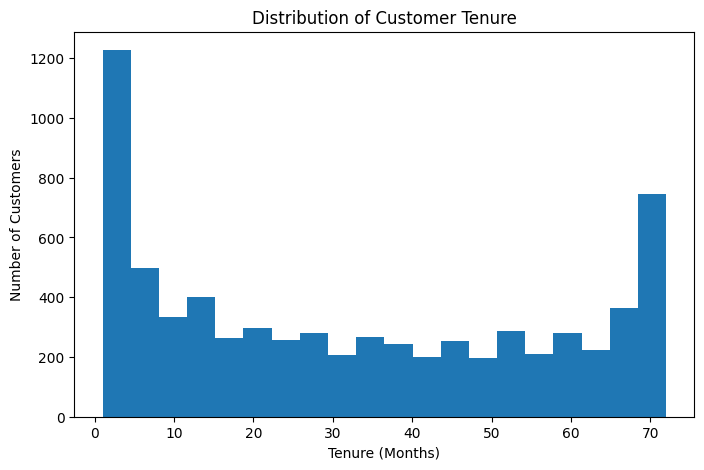

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(clean_df["tenure"], bins=20)
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Tenure")
plt.show()

### Interpretation

The distribution shows that customers have different lengths of tenure with the company. There are many customers with relatively short tenure, while the number of customers varies across the different tenure periods.

# Part 5 — Univariate EDA

## Numerical Feature 1 — Tenure


## Numerical Feature 2 — Monthly Charges

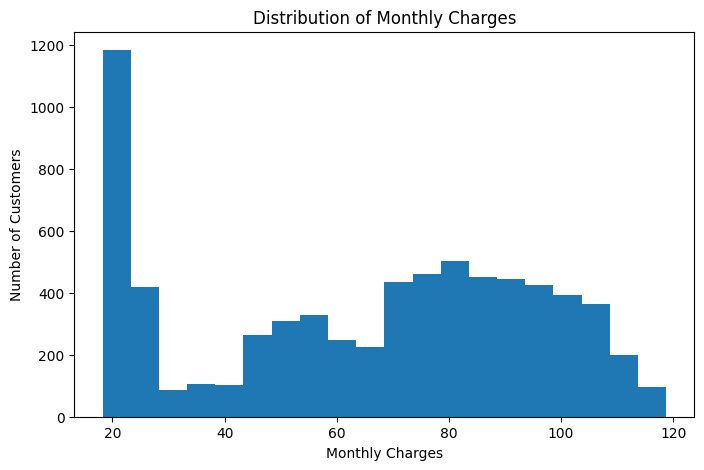

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(clean_df["MonthlyCharges"], bins=20)
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Distribution of Monthly Charges")
plt.show()

### Interpretation

The monthly charges show a range of prices paid by customers. The distribution indicates that customers do not all pay the same amount, with some customers paying considerably higher monthly charges than others.

## Categorical Feature 1 — Contract

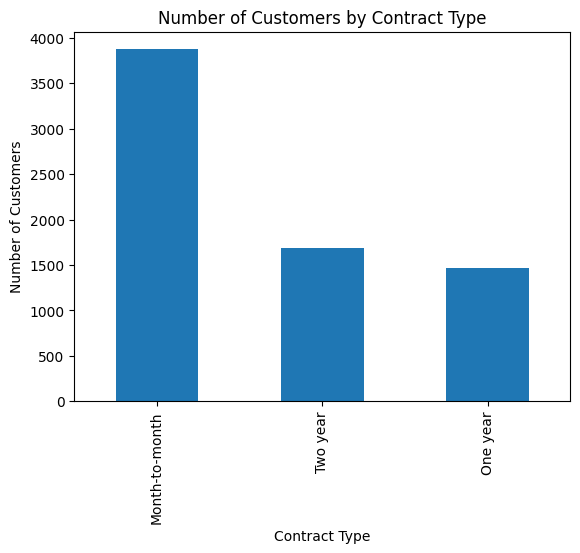

In [25]:
clean_df["Contract"].value_counts().plot(kind="bar")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Number of Customers by Contract Type")
plt.show()

### Interpretation

The chart shows the number of customers in each contract category. Month-to-month contracts represent a large portion of the customers, while one-year and two-year contracts have fewer customers.

## Categorical Feature 2 — Internet Service

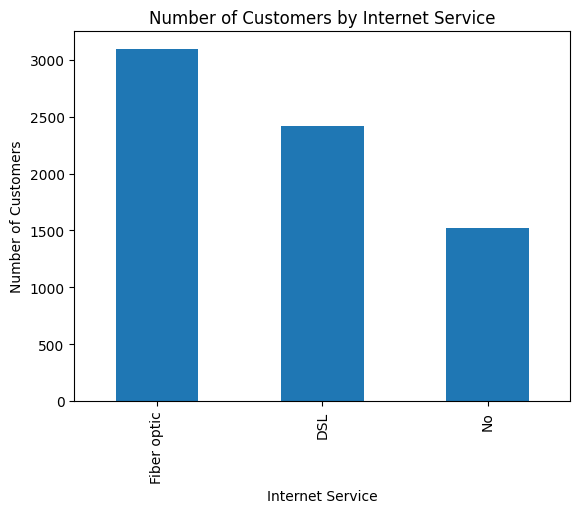

In [26]:
clean_df["InternetService"].value_counts().plot(kind="bar")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.title("Number of Customers by Internet Service")
plt.show()

### Interpretation

The chart shows how customers are distributed among DSL, Fiber optic, and customers without internet service. Fiber optic and DSL customers make up most of the internet-service customers, while a smaller group does not have internet service.

## Task 13 — Outliers and Skewed Distributions

Some numerical features may show skewness or outliers. MonthlyCharges can have higher values for customers using multiple services, while tenure can have many customers concentrated at particular lengths of service. These patterns may reflect differences in the services and contracts selected by customers.

# Part 6 — Target Variable Analysis

In [27]:
clean_df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [28]:
clean_df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

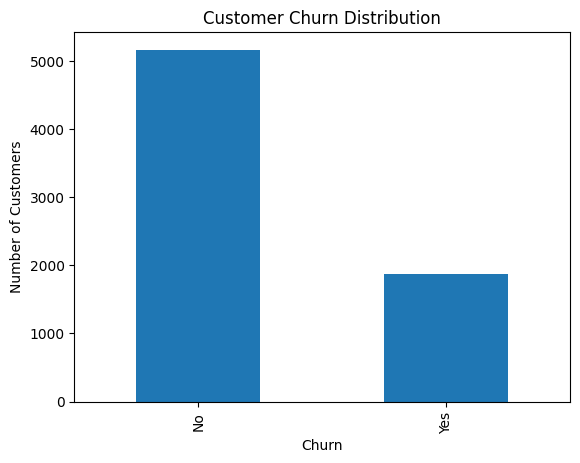

In [29]:
clean_df["Churn"].value_counts().plot(kind="bar")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.show()

### Task 14 — Churn Distribution

There are 5,174 customers who did not churn and 1,858 customers who churned.

The percentage of customers who did not churn is 73.58%, while 26.42% of customers churned. Therefore, the target variable is imbalanced because the two classes are not represented equally in the dataset.

## Task 15 — Why Class Imbalance Matters

Class imbalance matters because a model may become biased toward the majority class. A model could appear to have good overall accuracy while performing poorly at identifying customers who actually churn.

In [30]:
clean_df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [31]:
clean_df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

# Part 7 — Bivariate Analysis: Features vs. Churn

## Contract vs. Churn

In [32]:
contract_churn = pd.crosstab(
    clean_df["Contract"],
    clean_df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


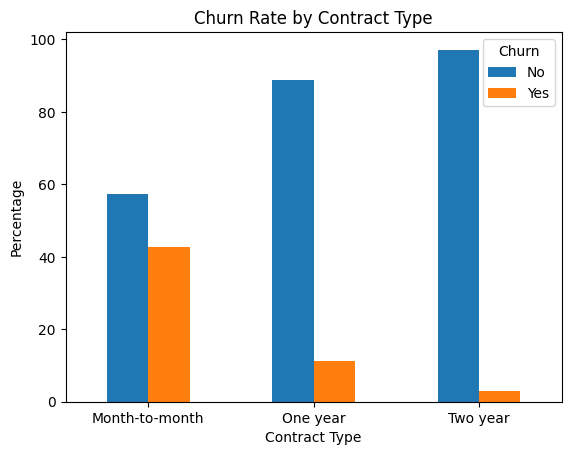

In [33]:
contract_churn.plot(kind="bar")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.title("Churn Rate by Contract Type")
plt.xticks(rotation=0)
plt.show()

### Observation / Evidence / Possible Explanation

**Observation:** Customers with month-to-month contracts have a higher churn rate than customers with one-year or two-year contracts.

**Evidence:** The crosstab and bar chart show that the percentage of customers who churn is highest for the month-to-month contract category.

**Possible Explanation:** Month-to-month customers have less long-term commitment and may find it easier to switch to another telecommunications provider.

## Internet Service vs. Churn

In [34]:
internet_churn = pd.crosstab(
    clean_df["InternetService"],
    clean_df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


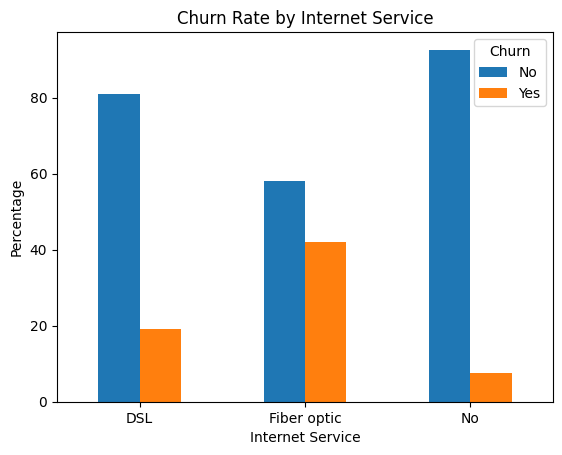

In [35]:
internet_churn.plot(kind="bar")
plt.xlabel("Internet Service")
plt.ylabel("Percentage")
plt.title("Churn Rate by Internet Service")
plt.xticks(rotation=0)
plt.show()

### Observation / Evidence / Possible Explanation

**Observation:** Churn rates differ between customers using different types of internet services.

**Evidence:** The crosstab shows different percentages of churn for DSL, Fiber optic, and customers without internet service.

**Possible Explanation:** Differences in service type, pricing, service quality, or customer expectations may contribute to different churn rates.

## Tenure vs. Churn

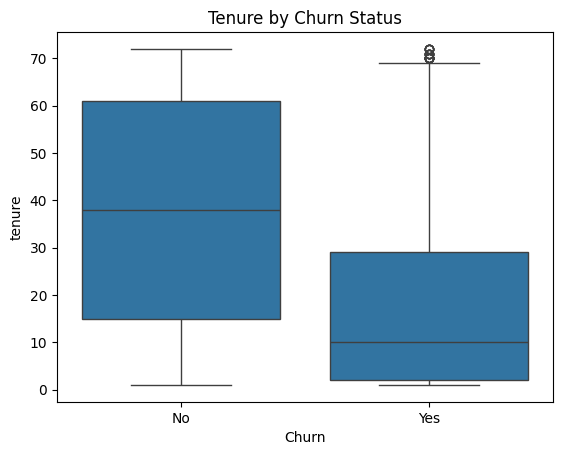

In [36]:
sns.boxplot(x="Churn", y="tenure", data=clean_df)
plt.title("Tenure by Churn Status")
plt.show()

### Observation / Evidence / Possible Explanation

**Observation:** Customers who churn generally have lower tenure than customers who do not churn.

**Evidence:** The boxplot shows that the tenure distribution for customers who churn is generally lower than the distribution for customers who remain.

**Possible Explanation:** Newer customers may have less loyalty or commitment to the company and may be more willing to switch providers.

## Monthly Charges vs. Churn

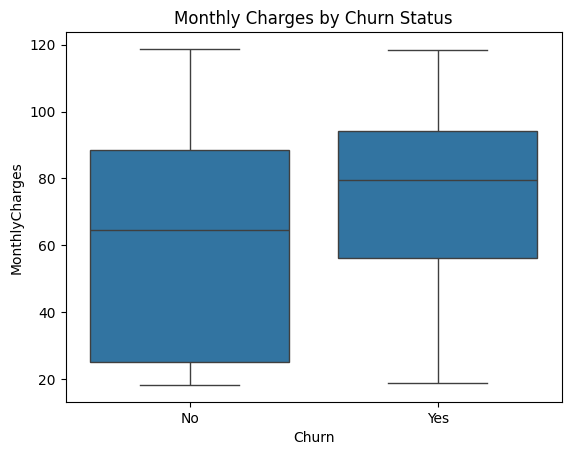

In [37]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=clean_df)
plt.title("Monthly Charges by Churn Status")
plt.show()

### Observation / Evidence / Possible Explanation

**Observation:** Customers who churn have monthly charges generally starting from a higher level compared with customers who do not churn.

**Evidence:** The boxplot shows that the monthly charge range for churned customers is approximately 60 to 90, while customers who did not churn have a wider range of approximately 23 to 90.

**Possible Explanation:** Customers with higher monthly charges may be more likely to leave because they may feel that their service is expensive compared with other available options.

# Part 8 — Correlation & Feature Relationships

In [38]:
corr_matrix = clean_df.corr(numeric_only=True)
corr_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


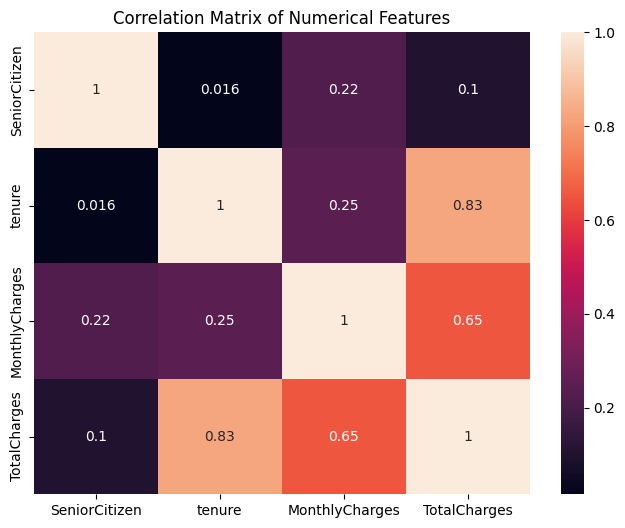

In [39]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

## Task 18 — Correlation Findings

The strongest positive correlation is between `tenure` and `TotalCharges`. This relationship makes sense because customers who have been with the company for a longer period generally accumulate higher total charges.

## Task 19 — Correlation Does Not Mean Causation

Correlation does not necessarily mean that one variable causes another. Highly correlated features can also provide similar information to a future model, which may create redundancy among the input features.

# Part 9 — Data Leakage Awareness

## Task 20 — Potential Leakage and Risky Features

The `customerID` column should not be used as a model input because it is only an identifier and does not provide meaningful information about customer behavior.

The `Churn` column should also not be used as an input feature because it is the target variable that we want the model to predict. Including the target as an input would cause data leakage.

`TotalCharges` should be considered carefully because it is strongly related to `tenure`. It may provide useful information, but the relationship should be considered when selecting features for a future model.

## Task 21 — Why Leakage Is Dangerous

Data leakage can make a machine-learning model appear to perform extremely well during training and evaluation because the model has access to information that would not legitimately be available when making predictions. This can lead to misleading results and poor performance when the model is used on new customers.

# Part 10 — ML-Readiness Checklist

## Task 22 — ML-Readiness Table

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | Identifier | Remove | It only identifies the customer and does not provide useful predictive information. |
| gender | Categorical | Feature | Encode | Machine-learning models generally require categorical values to be converted into numerical form. |
| SeniorCitizen | Numerical | Feature | Keep | It is a meaningful customer characteristic that may be useful for predicting churn. |
| Partner | Categorical | Feature | Encode | It contains categorical customer information that may be related to churn. |
| Dependents | Categorical | Feature | Encode | It provides information about the customer's household situation. |
| tenure | Numerical | Feature | Keep / Scale if needed | It is a numerical feature that may be related to customer retention. |
| PhoneService | Categorical | Feature | Encode | It is a categorical service-related feature. |
| MultipleLines | Categorical | Feature | Encode | It describes the customer's phone service and may provide useful information. |
| InternetService | Categorical | Feature | Encode | Different internet service types may have different churn behavior. |
| OnlineSecurity | Categorical | Feature | Encode | It describes an additional service and may be related to churn. |
| OnlineBackup | Categorical | Feature | Encode | It describes an additional service and may be useful for prediction. |
| DeviceProtection | Categorical | Feature | Encode | It provides information about subscribed services. |
| TechSupport | Categorical | Feature | Encode | It describes whether the customer has technical support service. |
| StreamingTV | Categorical | Feature | Encode | It provides information about subscribed services. |
| StreamingMovies | Categorical | Feature | Encode | It provides information about subscribed services. |
| Contract | Categorical | Feature | Encode | Contract type shows a strong relationship with churn. |
| PaperlessBilling | Categorical | Feature | Encode | It describes the customer's billing preference. |
| PaymentMethod | Categorical | Feature | Encode | Payment method may be associated with customer churn. |
| MonthlyCharges | Numerical | Feature | Keep / Scale if needed | It represents the customer's monthly billing amount. |
| TotalCharges | Numerical | Feature | Keep / Scale if needed | It represents the customer's accumulated charges after cleaning. |
| Churn | Categorical | Target | Keep as target | It is the outcome that the future model will predict and should not be used as an input feature. |

### ML-Readiness Summary

The cleaned dataset is mostly ready for machine-learning preprocessing. Categorical features will need to be encoded before being used by most machine-learning algorithms. Numerical features may require scaling depending on the selected model.

The `customerID` column should be excluded because it is only an identifier. The `Churn` column is the target variable and should not be used as an input feature.

# Part 11 — Building the Clean Dataset

## Task 23 — Build and Export the Clean Dataset

In [46]:
clean_df = clean_df.drop(columns=["customerID"])

clean_df.to_csv("clean_churn.csv", index=False)

In [47]:
final_df = pd.read_csv("clean_churn.csv")
final_df.head()
final_df.shape

(7032, 20)

## Task 24 — Final Dataset Verification

In [48]:
final_df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [49]:
final_df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [50]:
final_df.duplicated().sum()

np.int64(22)

# Part 12 — Key Findings & Final Reflection

## Task 25 — Five Key Findings

### Finding 1 — Data Quality

**Observation:** The original dataset contained 7,043 customer records and 21 columns. The `TotalCharges` column contained 11 blank values that were not initially detected as standard missing values.

**Evidence:** Converting `TotalCharges` to numeric using `pd.to_numeric()` with `errors="coerce"` identified 11 invalid values. Investigation showed that these customers had a tenure of 0 months.

**Interpretation:** The blank `TotalCharges` values appear to belong to newly joined customers who had not accumulated total charges yet.

### Finding 2 — Customer Churn

**Observation:** Most customers did not churn, while a smaller group of customers churned.

**Evidence:** There were 5,174 customers who did not churn and 1,858 customers who churned.

**Interpretation:** The target variable is imbalanced, with non-churned customers representing the majority of the dataset.

### Finding 3 — Contract Type

**Observation:** Month-to-month customers have a higher churn rate than customers with one-year or two-year contracts.

**Evidence:** The contract-versus-churn crosstab and bar chart show the highest churn percentage for month-to-month customers.

**Interpretation:** Customers without long-term contracts may have less commitment and may find it easier to switch to another provider.

### Finding 4 — Tenure

**Observation:** Customers who churn generally have lower tenure than customers who remain.

**Evidence:** The tenure boxplot shows that the distribution of tenure for churned customers is generally lower.

**Interpretation:** Newer customers may be more likely to leave because they have had less time to develop loyalty to the company.

### Finding 5 — Total Charges and Tenure

**Observation:** `tenure` and `TotalCharges` have a strong positive correlation.

**Evidence:** The correlation matrix shows that customers with longer tenure generally have higher total charges.

**Interpretation:** This relationship is logical because customers who stay longer have more time to accumulate charges. However, correlation does not prove that one variable causes the other.

## Task 26 — Final Reflection

### 1. What was the most important data-quality issue you found?

The most important data-quality issue was the 11 blank values in the `TotalCharges` column. These values were stored as blank strings, so they were not detected by the initial missing-value check. After converting the column to numeric, the 11 invalid values were identified and investigated. All affected customers had zero tenure.

### 2. What was the most interesting pattern you discovered?

The most interesting pattern was the relationship between contract type and churn. Month-to-month customers had a much higher churn rate than customers with one-year or two-year contracts.

### 3. Which feature seems most useful for predicting churn?

`Contract` appears to be one of the most useful features because the churn rate differs substantially across contract types. `tenure` also appears useful because customers who churn generally have lower tenure.

### 4. Which feature should probably not be used, and why?

`customerID` should probably not be used as a predictive feature because it is only an identifier and does not describe customer behavior. Including it would not provide meaningful information for predicting churn.

### 5. What preprocessing will be required before ML modeling?

Categorical features will need to be encoded into numerical values before many machine-learning models can use them. Numerical features may need scaling depending on the selected model. The target variable `Churn` will also need to be represented appropriately for classification.

### 6. What would you do next if you had another 3 hours?

With another three hours, I would investigate additional customer segments such as payment method, internet service, and combinations of contract type and tenure. I would also prepare the cleaned dataset for the next lab and then build and evaluate a classification model.